In [58]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
from matplotlib import pyplot as plt
from src.post_process_functions import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE
from src.accuracy import max_value_diff

In [2]:
#load data (model)
res_savename_ext = "post_processed_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v230925"
#extracted_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))

#load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_all_v240925"
#labelled_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_lab+".csv"))

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix+="_v250925"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix+".gpkg"))

#load data (labelled)
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix+".gpkg"))

#load matched data
filename_out = f"matched_data_labelled_extracted_row_matching_v120925"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_out + ".feather"))

In [3]:
#reformat output
from re import match


num_cols = ["impactValue", "geocoding_osm_flag", "geocoding_country_flag"]#"startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"
list_cols_ext = ["country", "location", "hazards", "valueAnnotation", "locationAnnotation", "dateAnnotation", "hazardsAnnotation"]
list_cols_lab = ["country", "location", "hazards", "annotation"]
labelled_df = format_output(labelled_df, num_cols=num_cols, list_cols=list_cols_lab)
extracted_df = format_output(extracted_df, num_cols=num_cols, list_cols=list_cols_ext)
DEF_CRS_EPSG = "EPSG:4326"
labelled_df = labelled_df.set_crs(DEF_CRS_EPSG, allow_override=True)
extracted_df = extracted_df.set_crs(DEF_CRS_EPSG, allow_override=True)
matched_df = matched_df.set_crs(DEF_CRS_EPSG, allow_override=True)

In [155]:
sim_cols = [match_col for match_col in matched_df.columns if "sim" in match_col and match_col not in ["lab_match_id_sim", "ext_match_id_sim"]]

In [4]:
matched_df[["appealCode", "match_sim", "impactSubtype", "impactSubtype_matched", "impactSubtype_sim", "impactValue", "impactValue_matched", "impactValue_error", "impactUnit","impactUnit_matched", "impactUnit_sim", "location", "location_matched", "geometry_sim", "valueAnnotation", "annotation_matched"]]

,appealCode,match_sim,impactSubtype,impactSubtype_matched,impactSubtype_sim,impactValue,impactValue_matched,impactValue_error,impactUnit,impactUnit_matched,impactUnit_sim,location,location_matched,geometry_sim,valueAnnotation,annotation_matched
0,MDRBD022,0.925,Affected People,Affected People,1.0,2176519.00,2176519.00,0.0,people,people,1.0,"[['[\'Kurigram\', \'Gaibandha\', \'Lalmonirhat...","[Kurigram district, Gaibandha district, Lalmon...",1.0,[According to National disaster response coord...,"[of affected population 2,176,519 No., Six day..."
1,MDRBD022,0.925,Displaced People,Displaced People,1.0,31818.00,31818.00,0.0,people,people,1.0,[],"[Kurigram district, Gaibandha district, Lalmon...",1.0,"[Situation at a glance, as of16 July2019 No. o...","[of people who have moved to safe shelter 31,8..."
2,MDRBD022,0.925,Residential Buildings,Residential Buildings,1.0,3988.00,3988.00,0.0,homes,homes,1.0,[],"[Kurigram district, Gaibandha district, Lalmon...",1.0,"[Situation at a glance, as of16 July2019 No. o...","[of fully damaged house 3,988 No., Six days of..."
3,MDRBD022,0.925,Residential Buildings,Residential Buildings,1.0,98571.00,98571.00,0.0,homes,homes,1.0,[],"[Kurigram district, Gaibandha district, Lalmon...",1.0,"[Situation at a glance, as of16 July2019 No. o...","[of partially damaged house 98,571 No., Six da..."
4,MDRBD022,0.575,Crop Production and Forestry,Crop Production and Forestry,1.0,147.33,147.33,0.0,km**2,km**2 of crop production and forestry,0.0,"[Kurigram, Gaibandha, Lalmonirhat, Chattogram,...","[Kurigram district, Gaibandha district, Lalmon...",1.0,[According to National disaster response coord...,"[of people who have moved to safe shelter 31,8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,MDRZM022,NaN,Access to Education,Affected Livestock and Animals,0.0,NaN,NaN,NaN,None,None,1.0,"[Southern Province, Central Province, Eastern ...","[North-Western province, Southern province, We...",1.0,[The situation has come at a time when the gov...,[Page 1 / 21 DREF Operation Zambia Drought 202...
467,MDRZM022,NaN,Access to Education,Other Economic and Livelihood Impacts,0.0,NaN,NaN,NaN,None,None,1.0,"[Southern Province, Central Province, Eastern ...","[North-Western province, Southern province, We...",1.0,[The situation has come at a time when the gov...,[Page 1 / 21 DREF Operation Zambia Drought 202...
468,MDRZM022,NaN,Access to Power and Energy,Water Quality and Availability,0.0,NaN,NaN,NaN,None,None,1.0,"[Southern Province, Western Province, North-We...","[North-Western province, Southern province, We...",1.0,[Pasture is drying up making is difficult for ...,[Page 1 / 21 DREF Operation Zambia Drought 202...
469,MDRZM022,NaN,Access to transport and Mobility,Affected Livestock and Animals,0.0,NaN,NaN,NaN,None,None,1.0,"[Southern Province, North-Western, Southern, W...","[North-Western province, Southern province, We...",1.0,[The whole Southern half of Zambia is experien...,[Page 1 / 21 DREF Operation Zambia Drought 202...


# Stats
1. Compare nb extracted impacts vs labelled (coverage)
    1. by reports
    2. by impact types
2. Compare matched rows 
    1. similarities on categories
    2. impactValue diff
    3. See if stats improve by taking higher level of aggreg (country level)


## Coverage by appeal

In [5]:
extracted_df["quanti"] = extracted_df["impactValue"].notnull()
labelled_df["quanti"] = labelled_df["impactValue"].notnull()

In [27]:
# coverage grouped by appeal
def make_coverage_appeal_df(extracted_df, labelled_df):
    df_list = []
    for qq in [True, False]:
        labelled_dfq = labelled_df[labelled_df["quanti"]==qq]
        extracted_dfq = extracted_df[extracted_df["quanti"]==qq]
        coverages_by_appeal = {}
        for appeal, group_lab in labelled_dfq.groupby("appealCode"):
            group_ext = extracted_dfq[extracted_dfq["appealCode"] == appeal]
            coverage = len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
            print(f"{appeal}: {len(group_ext)} extracted, {len(group_lab)} labelled, {coverage} coverage")
            coverages_by_appeal[appeal] = (len(group_ext), len(group_lab), coverage)
        df_list.append(pd.DataFrame(coverages_by_appeal, index=["nb extracted","nb labelled","coverage"]).T)

    return pd.concat(df_list, keys = ["quanti", "quali"]).reset_index(names=["quanti", "appealCode"])#.set_index("appealCode")
coverage_appeal_df = make_coverage_appeal_df(extracted_df, labelled_df)

MDRBD022: 10 extracted, 10 labelled, 1.0 coverage
MDRBJ019: 7 extracted, 18 labelled, 0.3888888888888889 coverage
MDRCM039: 9 extracted, 13 labelled, 0.6923076923076923 coverage
MDRCN006: 11 extracted, 15 labelled, 0.7333333333333333 coverage
MDRCO023: 2 extracted, 1 labelled, 2.0 coverage
MDRDZ011: 8 extracted, 9 labelled, 0.8888888888888888 coverage
MDRGE019: 5 extracted, 5 labelled, 1.0 coverage
MDRGT009: 9 extracted, 1 labelled, 9.0 coverage
MDRGW003: 8 extracted, 6 labelled, 1.3333333333333333 coverage
MDRHU005: 4 extracted, 1 labelled, 4.0 coverage
MDRIQ014: 5 extracted, 4 labelled, 1.25 coverage
MDRKE058: 19 extracted, 40 labelled, 0.475 coverage
MDRMY003: 4 extracted, 3 labelled, 1.3333333333333333 coverage
MDRMZ024: 12 extracted, 5 labelled, 2.4 coverage
MDRNG041: 8 extracted, 13 labelled, 0.6153846153846154 coverage
MDRPH021: 6 extracted, 7 labelled, 0.8571428571428571 coverage
MDRPK026: 9 extracted, 12 labelled, 0.75 coverage
MDRRW022: 13 extracted, 16 labelled, 0.8125 cover

In [6]:
## biased toward SV012 report
coverage_appeal_df.dropna()
nb_extracted = coverage_appeal_df.dropna()["nb extracted"].sum()
nb_labelled = coverage_appeal_df.dropna()["nb labelled"].sum()
avg_coverage_by_appeal = coverage_appeal_df.dropna()["coverage"].mean()
avg_coverage_tot = nb_extracted/nb_labelled


print(f"{nb_extracted} extracted, {nb_labelled} labelled, {avg_coverage_tot} coverage total, {avg_coverage_by_appeal} coverage by report")

403.0 extracted, 557.0 labelled, 0.7235188509874326 coverage total, 1.5213553702456548 coverage by report


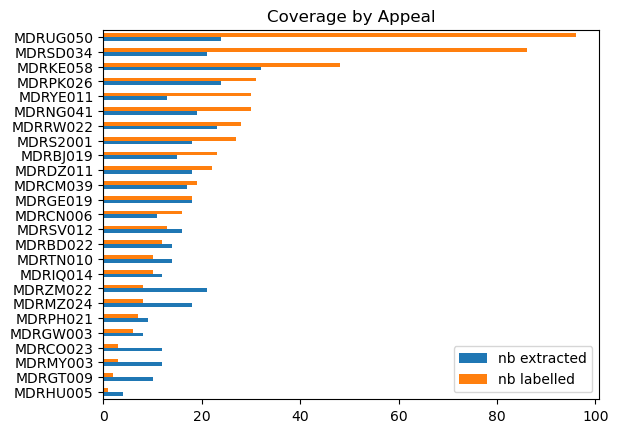

In [7]:
ax = coverage_appeal_df[["nb extracted", "nb labelled"]].sort_values("nb labelled", ascending=True).plot(kind="barh")
ax.set_title("Coverage by Appeal")
fig = ax.get_figure()
#fig.savefig(DATA_FIGURE / f"coverage_by_appeal_{dt.datetime.today().strftime('%d%m%y')}.png", bbox_inches="tight", dpi=300)

In [8]:
## investigate which rows have not been extracted
extracted_labelled_id = matched_df["lab_match_id_sim"]
labelled_df["extracted"] = labelled_df.index.isin(extracted_labelled_id)


In [9]:
labelled_df[labelled_df["appealCode"] == "MDRMZ024"][["extracted", "impactSubtype", "impactValue", "impactUnit", "location", "annotation"]]

,extracted,impactSubtype,impactValue,impactUnit,location,annotation
502,False,Affected People,61165.0,people,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
503,False,Affected People,153000.0,None,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
504,False,Other Infrastructure Impacts,NaN,None,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
505,False,Crop Production and Forestry,NaN,None,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
506,False,Other Service Access Impacts,NaN,None,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
507,False,Crop Production and Forestry,6900.0,km**2 of crop production and forestry,"[Tete, Gaza, Manica, Inhambane]",[1 OPERATION UPDATE Mozambique | Drought Emerg...
508,False,Access to Food,2700000.0,people,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
509,False,Other Economic and Livelihood Impacts,3.0,\% inflation rate,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...


In [10]:
extracted_df[extracted_df["appealCode"] == "MDRMZ024"][["impactSubtype", "impactValue", "impactUnit", "location", "valueAnnotation"]]

,impactSubtype,impactValue,impactUnit,location,valueAnnotation
63,Affected People,153000.0,people,[],[Tropical Storm Filipo in March2024 impacted15...
64,Affected People,6900.0,km**2 of crop production and forestry,[],"[As of April2024, approximately690,000 hectare..."
65,Affected People,61000.0,people,"[Tete, Gaza, Manica, Inhambane]","[Number of people being assisted:61,165 people..."
66,Crop Production and Forestry,6900.0,km**2 of crop production and forestry,"[Tete, Gaza, Manica, Inhambane]","[As of April2024, approximately690,000 hectare..."
67,Access to Food,2700000.0,people,"[Tete, Gaza, Manica, Inhambane]",[2.7 million people experiencing crisis levels...
68,Other Economic Activity & Livelihood Production,5000000.0,eur,"[Tete, Gaza, Manica, Inhambane]",[Funding requirements (CHF): CHF5 million thro...
69,Other Economic Activity & Livelihood Production,900000.0,chf,[],[Federation-wide DREF amount initially allocat...
70,Crop Production and Forestry,NaN,None,"[Tete, Gaza, Manica, Inhambane]","[Provinces such as Tete, Gaza, Manica, and Inh..."
71,Access to Food,NaN,None,"[Tete, Gaza, Manica, Inhambane]",[high competition for limited income opportuni...
72,Human Health and Wellbeing,NaN,None,"[Tete, Gaza, Manica, Inhambane]",[Mozambique National Institute of Statistics' ...


In [11]:
matched_df[matched_df["appealCode"] == "MDRUG050"][["impactSubtype", "impactSubtype_matched" ,"impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "location", "location_matched", "valueAnnotation", "annotation_matched"]]

,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,location,location_matched,valueAnnotation,annotation_matched
411,Affected People,Affected People,69.0,None,825.0,None,"[Central Region, Eastern Region, Western Regio...",[Bumwoni sub-county],"[In total, by August2024, the floods have affe...","[In Namisindwa, Bumwoni sub-county, a hailstor..."
412,Affected People,Affected People,18.0,None,825.0,None,"[Mbale, Kapchorwa, Bulambuli, Bukedea, Butalej...",[Bumwoni sub-county],"[18,323 people were affected, including thousa...","[In Namisindwa, Bumwoni sub-county, a hailstor..."
413,Affected People,Affected People,11.0,None,825.0,None,[Ntoroko district],[Bumwoni sub-county],"[11,775 individuals (2,355Households) have bee...","[In Namisindwa, Bumwoni sub-county, a hailstor..."
414,Injured People,Injured People,166.0,None,3.0,None,"[Butaleja district, Bukedi Sub County]",[Bumwoni sub-county],[This flooding also significantly affected hea...,"[In Namisindwa, Bumwoni sub-county, a hailstor..."
415,Injured People,Injured People,9.0,None,3.0,None,"[Mbale District, Bukasakya, Bungokho]",[Bumwoni sub-county],[This left109 people homeless and worsened san...,"[In Namisindwa, Bumwoni sub-county, a hailstor..."
416,Injured People,Injured People,6.0,None,3.0,None,"[['[""Bulambuli\'s Bunambutye sub-county""]']]",[Bumwoni sub-county],"[['[""On April3rd, floods hit Bulambuli\'s Buna...","[In Namisindwa, Bumwoni sub-county, a hailstor..."
417,Displaced People,Displaced People,10.0,None,2172.0,people,"[['[\'Central Region\', \'Eastern Region\', \'...",[Ntoroko district],"[In total, by August2024, the floods have affe...","[Further, Ntoroko district witnessed its ever-..."
418,Displaced People,Displaced People,3.0,None,2172.0,people,"[['[\'Bweramule Sub-County\', \'Butungama Sub-...",[Ntoroko district],"[3,080 Families were displaced and rendered ho...","[Further, Ntoroko district witnessed its ever-..."
419,Homeless People,Injured People,1.0,None,3.0,None,"[Sironko District, Bulambuli, Bunambutye sub-c...",[Bumwoni sub-county],[This event also damaged six water facilities ...,"[In Namisindwa, Bumwoni sub-county, a hailstor..."
420,Homeless People,Homeless People,327.0,None,1530.0,people,[Bweramule Sub-County],[Bookies sub-county],"[In Bweramule Sub-County,714 households were a...","[Moreover, floods struck Bookies sub-county, S..."


MDRBD022: 10 extracted, 10 labelled, 1.0 coverage
MDRBJ019: 7 extracted, 18 labelled, 0.3888888888888889 coverage
MDRCM039: 9 extracted, 13 labelled, 0.6923076923076923 coverage
MDRCN006: 11 extracted, 15 labelled, 0.7333333333333333 coverage
MDRCO023: 2 extracted, 1 labelled, 2.0 coverage
MDRDZ011: 8 extracted, 9 labelled, 0.8888888888888888 coverage
MDRGE019: 5 extracted, 5 labelled, 1.0 coverage
MDRGT009: 9 extracted, 1 labelled, 9.0 coverage
MDRGW003: 8 extracted, 6 labelled, 1.3333333333333333 coverage
MDRHU005: 4 extracted, 1 labelled, 4.0 coverage
MDRIQ014: 5 extracted, 4 labelled, 1.25 coverage
MDRKE058: 19 extracted, 40 labelled, 0.475 coverage
MDRMY003: 4 extracted, 3 labelled, 1.3333333333333333 coverage
MDRMZ024: 12 extracted, 5 labelled, 2.4 coverage
MDRNG041: 8 extracted, 13 labelled, 0.6153846153846154 coverage
MDRPH021: 6 extracted, 7 labelled, 0.8571428571428571 coverage
MDRPK026: 9 extracted, 12 labelled, 0.75 coverage
MDRRW022: 13 extracted, 16 labelled, 0.8125 cover

Text(0.5, 0.98, 'Coverage by Appeal')

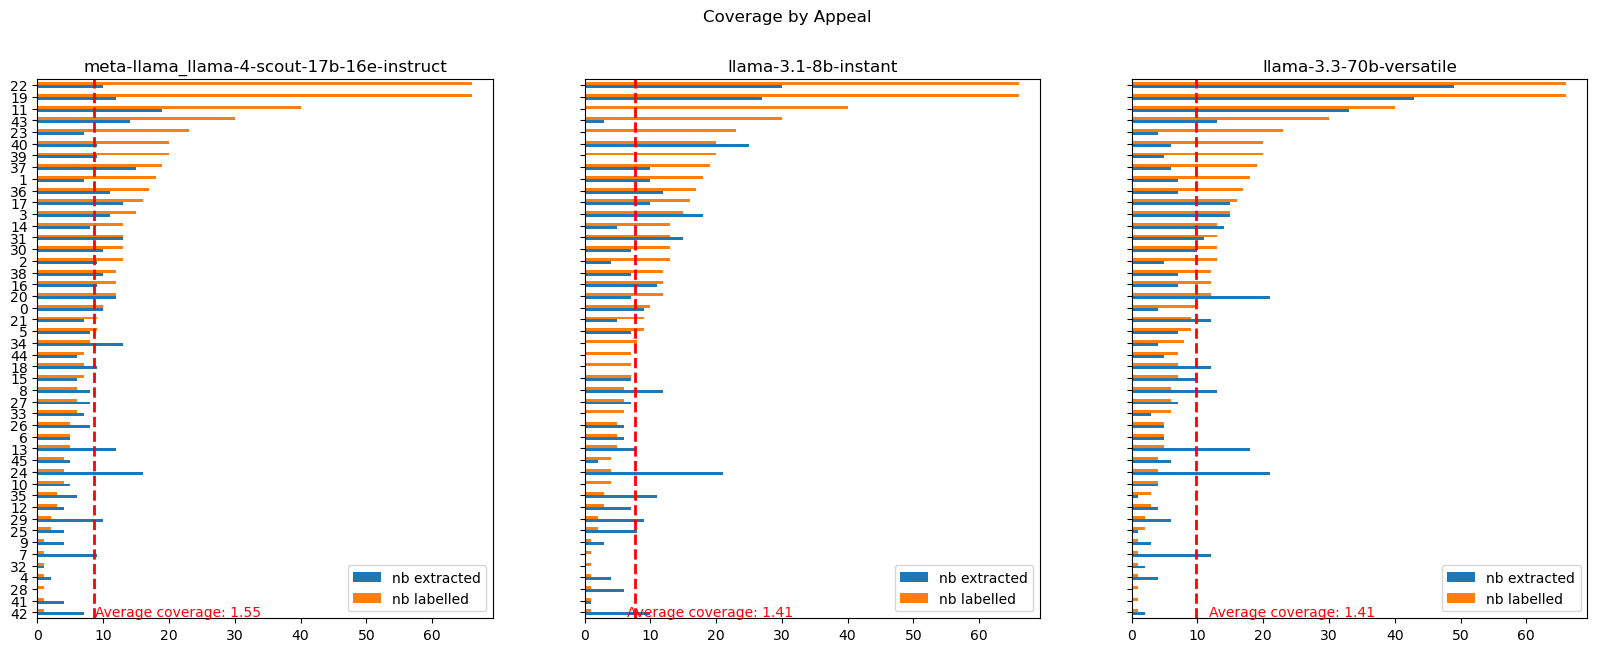

In [28]:
# compare different models
models = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
res_savename_ext1 = f"post_processed_labelled_reports_{models[0]}_v230925"
res_savename_ext2 = f"post_processed_labelled_reports_{models[1]}_v250925"
res_savename_ext3 = f"post_processed_labelled_reports_{models[2]}_v250925"

#load geocoded data
extracted_df1 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext1+".csv"))
extracted_df2 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext2+".csv"))
extracted_df3 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext3+".csv"))

extracted_df1["quanti"] = extracted_df1["impactValue"].notnull()
extracted_df2["quanti"] = extracted_df2["impactValue"].notnull()
extracted_df3["quanti"] = extracted_df3["impactValue"].notnull()
labelled_df["quanti"] = labelled_df["impactValue"].notnull()

coverage_appeal_df1 = make_coverage_appeal_df(extracted_df1, labelled_df)
coverage_appeal_df2 = make_coverage_appeal_df(extracted_df2, labelled_df)
coverage_appeal_df3 = make_coverage_appeal_df(extracted_df3, labelled_df)

fig, axes = plt.subplots(1, 3 ,figsize=(20,7), sharey=True)
coverage_appeal_df1[["nb extracted", "nb labelled"]].sort_values("nb labelled", ascending=True).plot(kind="barh", ax=axes[0])
coverage_appeal_df2[["nb extracted", "nb labelled"]].sort_values("nb labelled", ascending=True).plot(kind="barh", ax=axes[1])
coverage_appeal_df3[["nb extracted", "nb labelled"]].sort_values("nb labelled", ascending=True).plot(kind="barh", ax=axes[2])

#add averages
axes[0].axvline(coverage_appeal_df1["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)
axes[1].axvline(coverage_appeal_df2["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)
axes[2].axvline(coverage_appeal_df3["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)

axes[0].text(coverage_appeal_df1["nb extracted"].mean()*2.5, 0, f"Average coverage: {coverage_appeal_df1['coverage'].mean():.2f}", color="red", ha="center", va="center")
axes[1].text(coverage_appeal_df2["nb extracted"].mean()*2.5, 0, f"Average coverage: {coverage_appeal_df2['coverage'].mean():.2f}", color="red", ha="center", va="center")
axes[2].text(coverage_appeal_df3["nb extracted"].mean()*2.5, 0, f"Average coverage: {coverage_appeal_df3['coverage'].mean():.2f}", color="red", ha="center", va="center")

axes[0].set_title(models[0])
axes[1].set_title(models[1])
axes[2].set_title(models[2])

fig.suptitle("Coverage by Appeal")
#fig.savefig(DATA_FIGURE / f"coverage_by_appeal_{dt.datetime.today().strftime('%d%m%y')}.png", bbox_inches="tight", dpi=300)

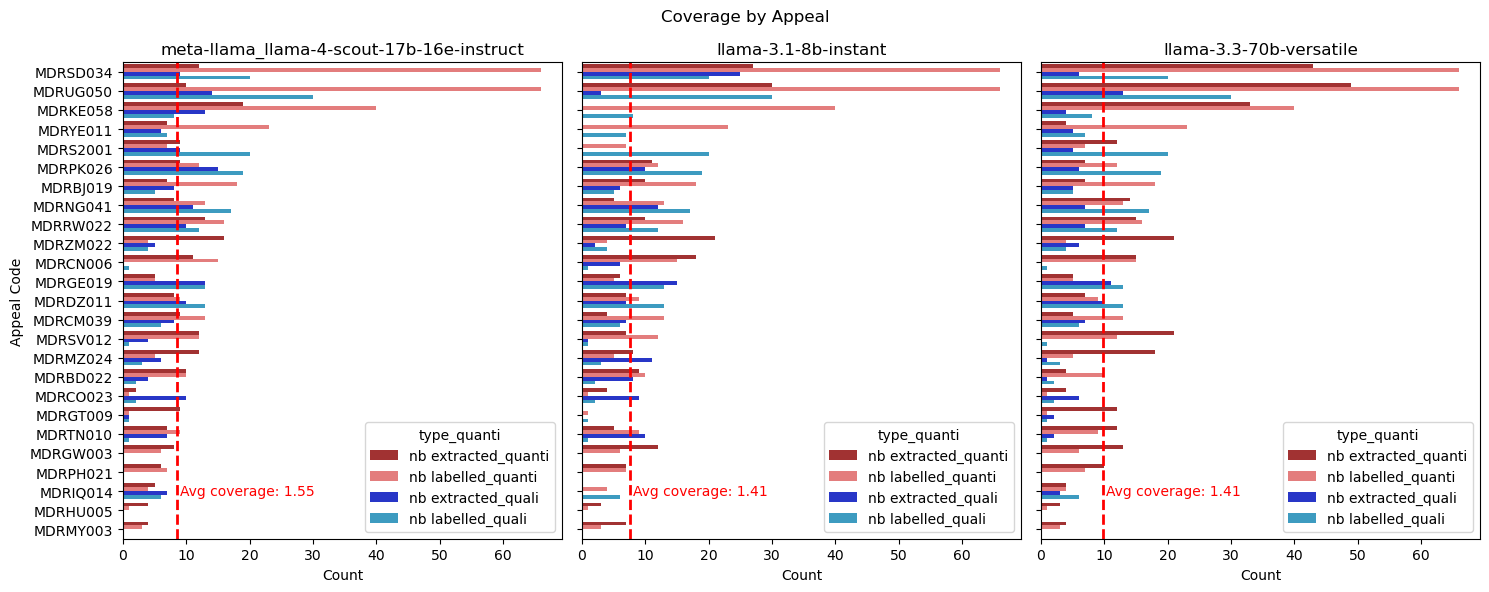

In [ ]:
import seaborn as sns

def plot_coverage_split_both(coverage_df, model_name, ax):
    # melt to long format
    df_melt = coverage_df.melt(
        id_vars=["appealCode", "quanti"],
        value_vars=["nb extracted", "nb labelled"],
        var_name="type", value_name="count"
    )

    # combine type + quanti into a single hue
    df_melt["type_quanti"] = df_melt["type"] + "_" + df_melt["quanti"].astype(str)

    # barplot with both factors in hue
    sns.barplot(
        data=df_melt.sort_values("count", ascending=False),
        x="count", y="appealCode",
        hue="type_quanti",
        hue_order=["nb extracted_quanti", "nb labelled_quanti", "nb extracted_quali", "nb labelled_quali"],
        palette=["#b41f1f", "#f46c6c", "#0e20e1", "#27a4d6"],ax=ax
    )

    # add average coverage line
    ax.axvline(coverage_df["nb extracted"].mean(), color="red", linestyle="--", linewidth=2)
    ax.text(
        coverage_df["nb extracted"].mean()*1.05,
        22,
        f"Avg coverage: {coverage_df['coverage'].mean():.2f}",
        color="red", ha="left", va="center"
    )

    ax.set_title(model_name)
    ax.set_xlabel("Count")
    ax.set_ylabel("Appeal Code")

# ---- plot all 3 models ----
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

plot_coverage_split_both(coverage_appeal_df1, models[0], axes[0])
plot_coverage_split_both(coverage_appeal_df2, models[1], axes[1])
plot_coverage_split_both(coverage_appeal_df3, models[2], axes[2])

fig.suptitle("Coverage by Appeal")
plt.tight_layout()


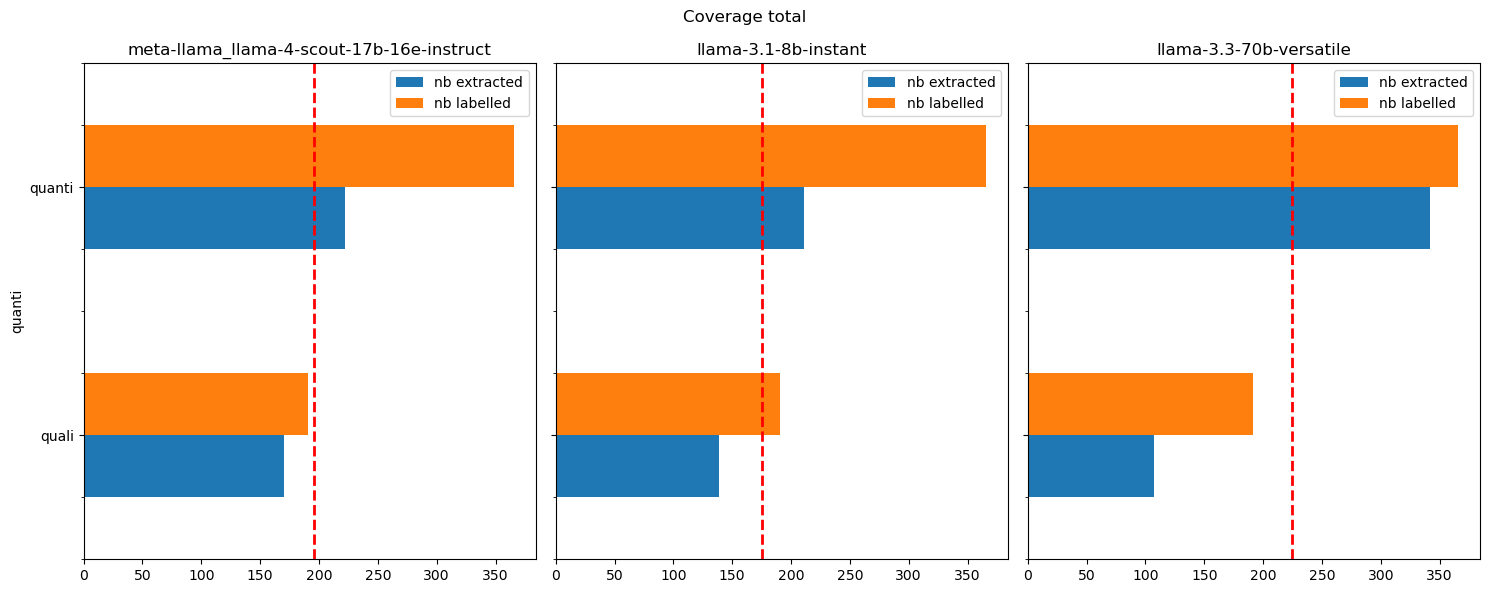

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

sumed_appeal1 = coverage_appeal_df1.groupby("quanti")[["nb extracted", "nb labelled"]].sum()
sumed_appeal1.plot(kind="barh", stacked=False, ax=axes[0]) # models[0], axes[0])
axes[0].axvline(sumed_appeal1["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)
axes[0].set_title(models[0])

sumed_appeal2 = coverage_appeal_df2.groupby("quanti")[["nb extracted", "nb labelled"]].sum()
sumed_appeal2.plot(kind="barh", stacked=False, ax=axes[1]) # models[1], axes[1])
axes[1].axvline(sumed_appeal2["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)
axes[1].set_title(models[1])

sumed_appeal3 = coverage_appeal_df3.groupby("quanti")[["nb extracted", "nb labelled"]].sum()
sumed_appeal3.plot(kind="barh", stacked=False, ax=axes[2]) # models[2], axes[2])
axes[2].axvline(sumed_appeal3["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)
axes[2].set_title(models[2])
#plot_coverage_split_both(coverage_appeal_df2, models[1], axes[1])
#plot_coverage_split_both(coverage_appeal_df3, models[2], axes[2])

fig.suptitle("Coverage total")
plt.tight_layout()


## Coverage with accuracy

In [205]:
#load data extracted for a specific model

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[2]
res_savename_ext = f"post_processed_flags_labelled_reports_{key}_v250925"
#load data (labelled)
res_savename_lab = "post_processed_flags_labelled_reports_impacts_all_v240925"

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix+="_v011025"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix+".gpkg"))
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix+".gpkg"))
#load corresponding matched data
filename_match = f"matched_data_ws2-geo-valuepost_{res_savename_ext}"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match + ".feather"))

DEF_CRS_EPSG = "EPSG:4326"

for df in [matched_df, extracted_df, labelled_df]:
    df["quanti"] = df["impactValue"].notnull()
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)

In [215]:
#define threshold above which we consider a match
value_error_th = 0.05
sim_th = 0.6

matched_df_filter_qt = matched_df.copy()
matched_df_filter_qt = matched_df_filter_qt[(matched_df_filter_qt["impactValue_error"] <= value_error_th) & (matched_df_filter_qt["quanti"])]
matched_df_filter_ql = matched_df.copy()
matched_df_filter_ql = matched_df_filter_ql[(matched_df_filter_ql["match_sim"] >= sim_th) & (~matched_df_filter_ql["quanti"])]
matched_df_filter = pd.concat([matched_df_filter_qt, matched_df_filter_ql], axis=0)
def make_coverage_accuracy_appeal_df(extracted_df, labelled_df, matched_df, value_error_th=0.05, sim_th=0.6):
    #filter matches
    matched_df_filter_qt = matched_df.copy()
    matched_df_filter_qt = matched_df_filter_qt[(matched_df_filter_qt["impactValue_error"] <= value_error_th) & (matched_df_filter_qt["quanti"])]
    matched_df_filter_ql = matched_df.copy()
    matched_df_filter_ql = matched_df_filter_ql[(matched_df_filter_ql["match_sim"] >= sim_th) & (~matched_df_filter_ql["quanti"])]
    matched_df_filter = pd.concat([matched_df_filter_qt, matched_df_filter_ql], axis=0)

    df_list = []
    for qq in [True, False]:
        labelled_dfq = labelled_df[labelled_df["quanti"]==qq]
        extracted_dfq = extracted_df[extracted_df["quanti"]==qq]
        matched_df_filterq = matched_df_filter[matched_df_filter["quanti"]==qq]
        coverages_by_appeal = {}
        for appeal, group_lab in labelled_dfq.groupby("appealCode"):
            group_ext = extracted_dfq[extracted_dfq["appealCode"] == appeal]
            group_ext_match = matched_df_filterq[matched_df_filterq["appealCode"] == appeal]
            coverage = 100*len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
            coverage_match = 100*group_ext_match["lab_match_id_sim"].nunique()/len(group_lab) if len(group_lab) > 0 else np.nan
            garbage = 100*(max(0,len(group_ext) - group_ext_match["lab_match_id_sim"].nunique())) / len(group_ext) if len(group_ext) > 0 else 0
            print(f"{appeal}: {len(group_ext)} extracted, {len(group_lab)} labelled, {coverage} coverage")
            coverages_by_appeal[appeal] = (len(group_ext), len(group_lab), group_ext_match["lab_match_id_sim"].nunique(), coverage, coverage_match, garbage)
        df_list.append(pd.DataFrame(coverages_by_appeal, index=["nb extracted","nb labelled", "nb matches","coverage", "coverage matches", "garbage"]).T)

    return pd.concat(df_list, keys = ["quanti", "quali"]).reset_index(names=["quanti", "appealCode"])


In [216]:
coverage_df_match = make_coverage_accuracy_appeal_df(extracted_df, labelled_df, matched_df, value_error_th=0.05, sim_th=0.6)

MDRBD022: 4 extracted, 10 labelled, 40.0 coverage
MDRBJ019: 7 extracted, 18 labelled, 38.888888888888886 coverage
MDRCM039: 5 extracted, 13 labelled, 38.46153846153846 coverage
MDRCN006: 15 extracted, 15 labelled, 100.0 coverage
MDRCO023: 4 extracted, 1 labelled, 400.0 coverage
MDRDZ011: 7 extracted, 9 labelled, 77.77777777777777 coverage
MDRGE019: 5 extracted, 5 labelled, 100.0 coverage
MDRGT009: 12 extracted, 1 labelled, 1200.0 coverage
MDRGW003: 13 extracted, 6 labelled, 216.66666666666666 coverage
MDRHU005: 3 extracted, 1 labelled, 300.0 coverage
MDRIQ014: 4 extracted, 4 labelled, 100.0 coverage
MDRKE058: 33 extracted, 40 labelled, 82.5 coverage
MDRMY003: 4 extracted, 3 labelled, 133.33333333333334 coverage
MDRMZ024: 18 extracted, 5 labelled, 360.0 coverage
MDRNG041: 14 extracted, 13 labelled, 107.6923076923077 coverage
MDRPH021: 10 extracted, 7 labelled, 142.85714285714286 coverage
MDRPK026: 7 extracted, 12 labelled, 58.333333333333336 coverage
MDRRW022: 15 extracted, 16 labelled,

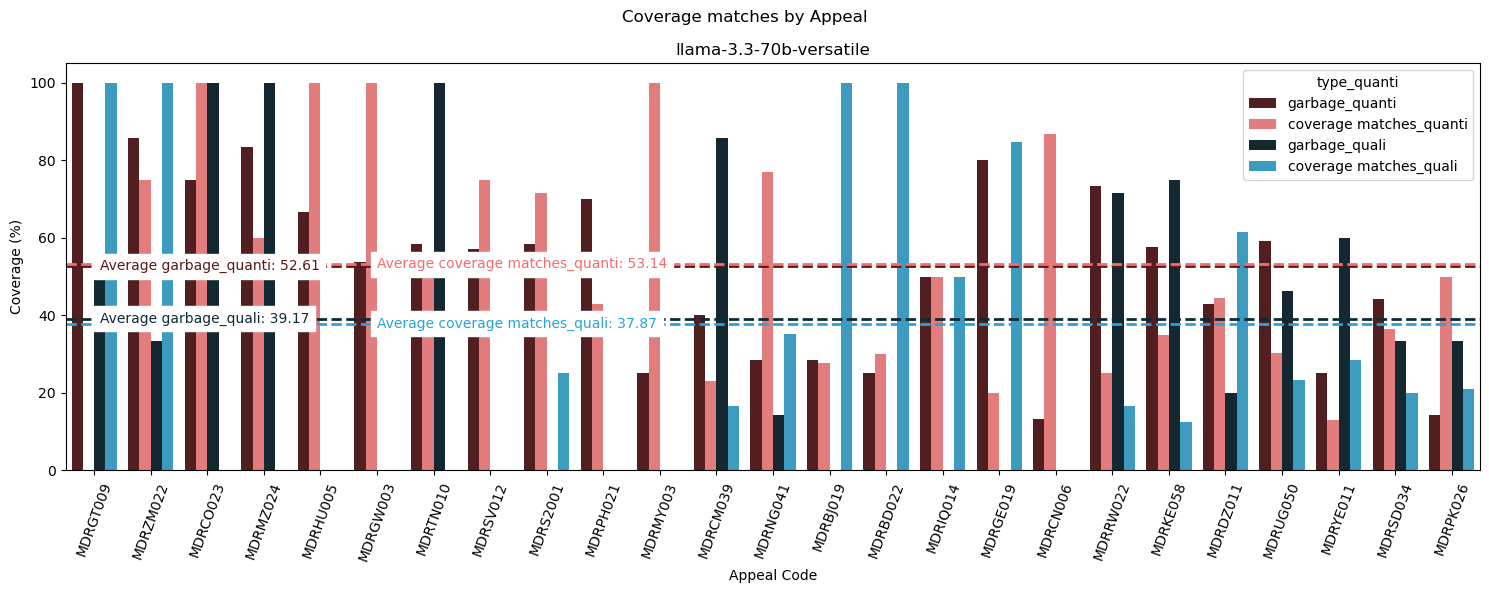

In [226]:
from matplotlib.patches import bbox_artist


def plot_coverage_match(coverage_df_match, key, ax, relative=True):
    if relative:
        value_vars = ["coverage", "coverage matches", "garbage"]
        hue_order = ["garbage_quanti", "coverage matches_quanti", "garbage_quali", "coverage matches_quali"]
        #["coverage_quanti", "coverage matches_quanti", "coverage_quali", "coverage matches_quali"]
        palette = ["#591717", "#f46c6c","#0e2a35","#27a4d6"]
        #["#b41f1f", "#f46c6c", "#0e20e1", "#27a4d6"]
        label = "Coverage (%)"
    else:
        value_vars = ["nb extracted", "nb labelled", "nb matches"]
        hue_order = ["nb extracted_quanti", "nb labelled_quanti", "nb matches_quanti", "nb extracted_quali", "nb labelled_quali", "nb matches_quali"]
        palette=["#b41f1f", "#f46c6c", "#FF04EE","#0e20e1", "#27a4d6", "#00ffb7"]
        label = "Number of matches"
    df_melt = coverage_df_match.melt(
        id_vars=["appealCode", "quanti"],
        value_vars=value_vars,
        var_name="type", value_name="count"
    )

    # combine type + quanti into a single hue
    df_melt["type_quanti"] = df_melt["type"] + "_" + df_melt["quanti"].astype(str)
    # barplot with both factors in hue
    sns.barplot(
        data=df_melt.sort_values("count", ascending=False),
        x="appealCode", y="count",
        hue="type_quanti",
        hue_order=hue_order,
        palette=palette,
        ax=ax
    )
    #add average coverage line
    posis = [0.1, 5, 0.1, 5]
    for i, lab in enumerate(hue_order):
        mean_val = df_melt[df_melt["type_quanti"] == lab].groupby("appealCode")["count"].mean().mean()
        ax.axhline(mean_val, color=palette[i], linestyle="--", linewidth=2)
        ax.text(
            posis[i], mean_val, f"Average {lab}: {mean_val:.2f}"
            , color=palette[i], ha="left", va="center", backgroundcolor="white"
        )

    ax.set_title(key)
    ax.set_xlabel("Appeal Code")
    ax.set_ylabel(label)
    plt.xticks(rotation=70);
# ---- plot all 3 models ----
fig, axes = plt.subplots(1, 1, figsize=(15, 6), sharey=True)

plot_coverage_match(coverage_df_match, key, axes)

fig.suptitle("Coverage matches by Appeal")
plt.tight_layout()
#fig.savefig(DATA_FIGURE / f"coverage_matches_by_appeal_{res_savename_ext}.png", bbox_inches="tight", dpi=300)

In [219]:
coverage_df_match[coverage_df_match["appealCode"] == "MDRBD022"]

,quanti,appealCode,nb extracted,nb labelled,nb matches,coverage,coverage matches,garbage
0,quanti,MDRBD022,4.0,10.0,3.0,40.0,30.0,25.0
25,quali,MDRBD022,1.0,2.0,2.0,50.0,100.0,0.0


In [220]:
matched_df[matched_df["appealCode"] == "MDRBD022"][["appealCode", "impactSubtype", "impactSubtype_matched" ,"impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "location", "location_matched", "valueAnnotation", "annotation_matched"]]

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,location,location_matched,valueAnnotation,annotation_matched
0,MDRBD022,Affected People,Affected People,2176519.00,people,2176519.00,people,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",['According to National disaster response coor...,"['of affected population 2,176,519 No.', 'Six ..."
1,MDRBD022,Residential Buildings,Residential Buildings,39859.00,homes,3988.00,homes,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...","['No. of fully damaged house 3,988 No. of part...","['of fully damaged house 3,988 No.', 'Six days..."
2,MDRBD022,Crop Production and Forestry,Crop Production and Forestry,147.33,km**2 of crop production and forestry,147.33,km**2 of crop production and forestry,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...","['Amount of crop land damaged (Hectare) 14,733']","['of people who have moved to safe shelter 31,..."
3,MDRBD022,Residential Buildings,Residential Buildings,100000.00,homes,98571.00,homes,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",['According to National disaster response coor...,"['of partially damaged house 98,571 No.', 'Six..."
4,MDRBD022,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,nan,NaN,nan,[],"['Kurigram district', 'Gaibandha district', 'L...",['It is also reported that embankments have be...,['It is also reported that embankments have be...
5,MDRBD022,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,nan,NaN,nan,[],"['Gaddimari area', 'Lalmonirhats Hatibandha']",['It is also reported that embankments have be...,['of union affected 776 Emergency Plan of Acti...


In [203]:
from src.post_process_functions import reclassify_units
from src.units import unit_kw_reclass, default_subtype_unit
matched_df.apply(reclassify_units, unit_kw_reclass=unit_kw_reclass, default_subtype_unit=default_subtype_unit, force_unit_to_subtype=False, reclass_subtype=True, axis=1)

Reclassified subtype from Other Infrastructural Impacts to Residential Buildings with unit reclass homes and orig unit homes
Reclassified subtype from Access to Food to Water, Sanitation, and Hygiene Infrastructure with unit reclass water, sanitation and hygiene facilities and orig unit water, sanitation and hygiene facilities
Reclassified subtype from Human Health and Wellbeing to Water, Sanitation, and Hygiene Infrastructure with unit reclass water, sanitation and hygiene facilities and orig unit water, sanitation and hygiene facilities
Reclassified subtype from Human Health and Wellbeing to Water, Sanitation, and Hygiene Infrastructure with unit reclass water, sanitation and hygiene facilities and orig unit water, sanitation and hygiene facilities
Reclassified subtype from Affected Livestock and Animals to Residential Buildings with unit reclass homes and orig unit homes
Reclassified subtype from Affected Livestock and Animals to Residential Buildings with unit reclass homes and ori

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,match_sim,impactValue_error,quanti,impactValue_sim,flag_unit_nonstd,flag_reclass_subtype_from_unit
0,Affected People,2176519.00,NaN,NaN,exact,people,['According to National disaster response coor...,['Bangladesh'],"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...",['Six days of heavy rain and onrush of upstrea...,...,0.0,1.0,1.0,0.999197,0.899960,0.000000,True,1.000000,False,False
1,Affected People,2176519.00,NaN,NaN,exact,people,['According to National disaster response coor...,['Bangladesh'],"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...",['Six days of heavy rain and onrush of upstrea...,...,0.0,1.0,1.0,0.999197,0.899960,0.000000,True,1.000000,False,False
2,Residential Buildings,39859.00,NaN,NaN,exact,homes,"['No. of fully damaged house 3,988 No. of part...",['Bangladesh'],"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...",['Six days of heavy rain and onrush of upstrea...,...,0.0,1.0,1.0,0.999197,0.899960,8.994734,True,0.000000,False,False
3,Crop Production and Forestry,147.33,NaN,NaN,exact,km**2 of crop production and forestry,"['Amount of crop land damaged (Hectare) 14,733']",['Bangladesh'],"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...",['Six days of heavy rain and onrush of upstrea...,...,0.0,1.0,1.0,0.999197,0.899960,0.000000,True,1.000000,False,False
4,Residential Buildings,100000.00,NaN,NaN,exact,homes,['According to National disaster response coor...,['Bangladesh'],"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...",['Six days of heavy rain and onrush of upstrea...,...,0.0,0.0,1.0,0.999197,0.549960,0.014497,True,0.985503,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,Other Agricultural Impacts,NaN,NaN,NaN,None,none,"['Crops especially maize, legumes, grounds nut...",['Zambia'],"['Southern Province', 'North-Western', 'Wester...",['The whole Southern half of Zambia is experie...,...,0.0,0.0,1.0,0.968290,0.523415,NaN,False,NaN,True,False
644,Other Economic Activity & Livelihood Production,NaN,NaN,NaN,None,none,['Price for food items and other basic commodi...,['Zambia'],"['Southern Province', 'Gwembe', 'Sinazongwe', ...",['The whole Southern half of Zambia is experie...,...,0.0,0.0,1.0,0.639986,0.506999,NaN,False,NaN,True,False
645,Other Economic Activity & Livelihood Production,NaN,NaN,NaN,None,none,['Price for food items and other basic commodi...,['Zambia'],"['Southern Province', 'Gwembe', 'Sinazongwe', ...",['The whole Southern half of Zambia is experie...,...,0.0,0.0,1.0,0.639986,0.506999,NaN,False,NaN,True,False
646,Other Economic Activity & Livelihood Production,NaN,NaN,NaN,None,none,['Price for food items and other basic commodi...,['Zambia'],"['Southern Province', 'Gwembe', 'Sinazongwe', ...",['The whole Southern half of Zambia is experie...,...,0.0,0.0,1.0,0.639986,0.506999,NaN,False,NaN,True,False


In [146]:
coverage_df_match[coverage_df_match["appealCode"] == "MDRHU005"]

,quanti,appealCode,nb extracted,nb labelled,nb matches,coverage,coverage matches
9,quanti,MDRHU005,4.0,1.0,2.0,400.0,200.0


In [156]:
matched_df[matched_df["appealCode"] == "MDRHU005"][sim_cols]

,hazards_sim,country_sim,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,match_sim,impactValue_sim
260,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.20,0.000000
261,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.55,1.000000
262,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.90,1.000000
263,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.20,0.770492


In [148]:
labelled_df[labelled_df["appealCode"] == "MDRHU005"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,country_iso3_kw,unit_type,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti
554,2016-11-29,Residential Buildings,750.0,homes,approx,750.0,NaN,"['On 21 June 2016, heavy rain and hailstorm hi...",['Hungary'],['Szabolcs-Szatmr-Bereg County'],...,NaN,other,ADM_0,1,0,['Hungary'],['Hungary'],['HUN'],"MULTIPOLYGON (((16.11381 46.86909, 16.11381 46...",True


In [152]:
extracted_df[extracted_df["appealCode"] == "MDRHU005"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,country_iso3_kw,unit_type,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti
389,Affected People,2282.0,NaN,NaN,exact,people,['Number of people affected: up to approximate...,['Hungary'],['Szabolcs-Szatmár-Bereg County'],"['On21 June2016, heavy rain and hailstorm hit ...",...,HUN,other,ADM_0,1,0,['Hungary'],['Hungary'],['HUN'],"MULTIPOLYGON (((16.11381 46.86909, 16.11381 46...",True
390,Residential Buildings,750.0,NaN,NaN,exact,None,['It was reported by the National Directorate ...,['Hungary'],['Szabolcs-Szatmár-Bereg County'],"['On21 June2016, heavy rain and hailstorm hit ...",...,HUN,other,ADM_0,1,0,['Hungary'],['Hungary'],['HUN'],"MULTIPOLYGON (((16.11381 46.86909, 16.11381 46...",True
391,Residential Buildings,750.0,NaN,NaN,exact,homes,['It was reported by the National Directorate ...,['Hungary'],['Szabolcs-Szatmár-Bereg County'],"['On21 June2016, heavy rain and hailstorm hit ...",...,HUN,other,ADM_0,1,0,['Hungary'],['Hungary'],['HUN'],"MULTIPOLYGON (((16.11381 46.86909, 16.11381 46...",True
392,Affected People,610.0,NaN,NaN,exact,people,['Number of people to assisted: approximately6...,['Hungary'],['Szabolcs-Szatmár-Bereg County'],"['On21 June2016, heavy rain and hailstorm hit ...",...,HUN,other,ADM_0,1,0,['Hungary'],['Hungary'],['HUN'],"MULTIPOLYGON (((16.11381 46.86909, 16.11381 46...",True


## Coverage by subtype

In [149]:
# coverage grouped by impactSubtype
def make_coverage_subtype_df(extracted_df, labelled_df):
    coverages_by_subtype = {}
    n_ext = len(extracted_df)
    n_lab = len(labelled_df)
    for subtype, group_ext in extracted_df.groupby("impactSubtype"):
        group_lab = labelled_df[labelled_df["impactSubtype"] == subtype]
        coverage = len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
        coverage_rel_ext = len(group_ext) / n_ext
        coverage_rel_lab = len(group_lab) / n_lab
        print(f"{subtype}: {len(group_ext)} extracted, {len(group_lab)} labelled, {coverage} coverage")
        coverages_by_subtype[subtype] = (len(group_ext), len(group_lab), coverage, coverage_rel_ext, coverage_rel_lab)
    return pd.DataFrame(coverages_by_subtype, index=["nb extracted","nb labelled","coverage", "coverage_rel_ext", "coverage_rel_lab"]).T

coverage_subtype_df = make_coverage_subtype_df(extracted_df, labelled_df)

Access to Education: 4 extracted, 2 labelled, 2.0 coverage
Access to Food: 26 extracted, 10 labelled, 2.6 coverage
Access to Healthcare: 17 extracted, 6 labelled, 2.8333333333333335 coverage
Access to Power and Energy: 4 extracted, 4 labelled, 1.0 coverage
Access to Water, Sanitation, and Hygiene: 17 extracted, 4 labelled, 4.25 coverage
Affected Livestock and Animals: 16 extracted, 14 labelled, 1.1428571428571428 coverage
Affected People: 44 extracted, 106 labelled, 0.41509433962264153 coverage
Agricultural Infrastructure: 14 extracted, 2 labelled, 7.0 coverage
Crop Production and Forestry: 20 extracted, 33 labelled, 0.6060606060606061 coverage
Displaced People: 19 extracted, 38 labelled, 0.5 coverage
Education Infrastructure: 6 extracted, 11 labelled, 0.5454545454545454 coverage
Healthcare Infrastructure: 6 extracted, 12 labelled, 0.5 coverage
Homeless People: 14 extracted, 9 labelled, 1.5555555555555556 coverage
Human Deaths: 15 extracted, 26 labelled, 0.5769230769230769 coverage
Hum

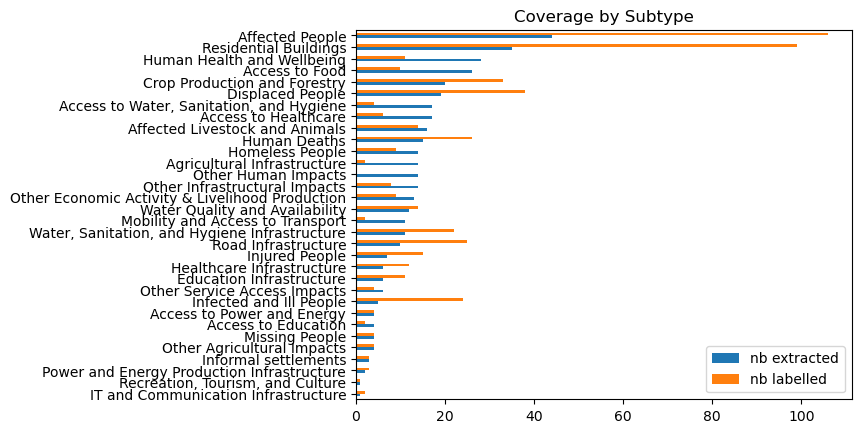

In [24]:
ax = coverage_subtype_df[["nb extracted", "nb labelled"]].sort_values("nb extracted", ascending=True).plot(kind="barh")
ax.set_title("Coverage by Subtype")
fig = ax.get_figure()
#fig.savefig(DATA_FIGURE / f"coverage_by_subtype_{dt.datetime.today().strftime('%d%m%y')}.png", bbox_inches="tight", dpi=300)

Access to Education: 4 extracted, 2 labelled, 2.0 coverage
Access to Food: 26 extracted, 10 labelled, 2.6 coverage
Access to Healthcare: 17 extracted, 6 labelled, 2.8333333333333335 coverage
Access to Power and Energy: 4 extracted, 4 labelled, 1.0 coverage
Access to Water, Sanitation, and Hygiene: 17 extracted, 4 labelled, 4.25 coverage
Affected Livestock and Animals: 16 extracted, 14 labelled, 1.1428571428571428 coverage
Affected People: 44 extracted, 106 labelled, 0.41509433962264153 coverage
Agricultural Infrastructure: 14 extracted, 2 labelled, 7.0 coverage
Crop Production and Forestry: 20 extracted, 33 labelled, 0.6060606060606061 coverage
Displaced People: 19 extracted, 38 labelled, 0.5 coverage
Education Infrastructure: 6 extracted, 11 labelled, 0.5454545454545454 coverage
Healthcare Infrastructure: 6 extracted, 12 labelled, 0.5 coverage
Homeless People: 14 extracted, 9 labelled, 1.5555555555555556 coverage
Human Deaths: 15 extracted, 26 labelled, 0.5769230769230769 coverage
Hum

Text(0.5, 0.98, 'Coverage by subtype')

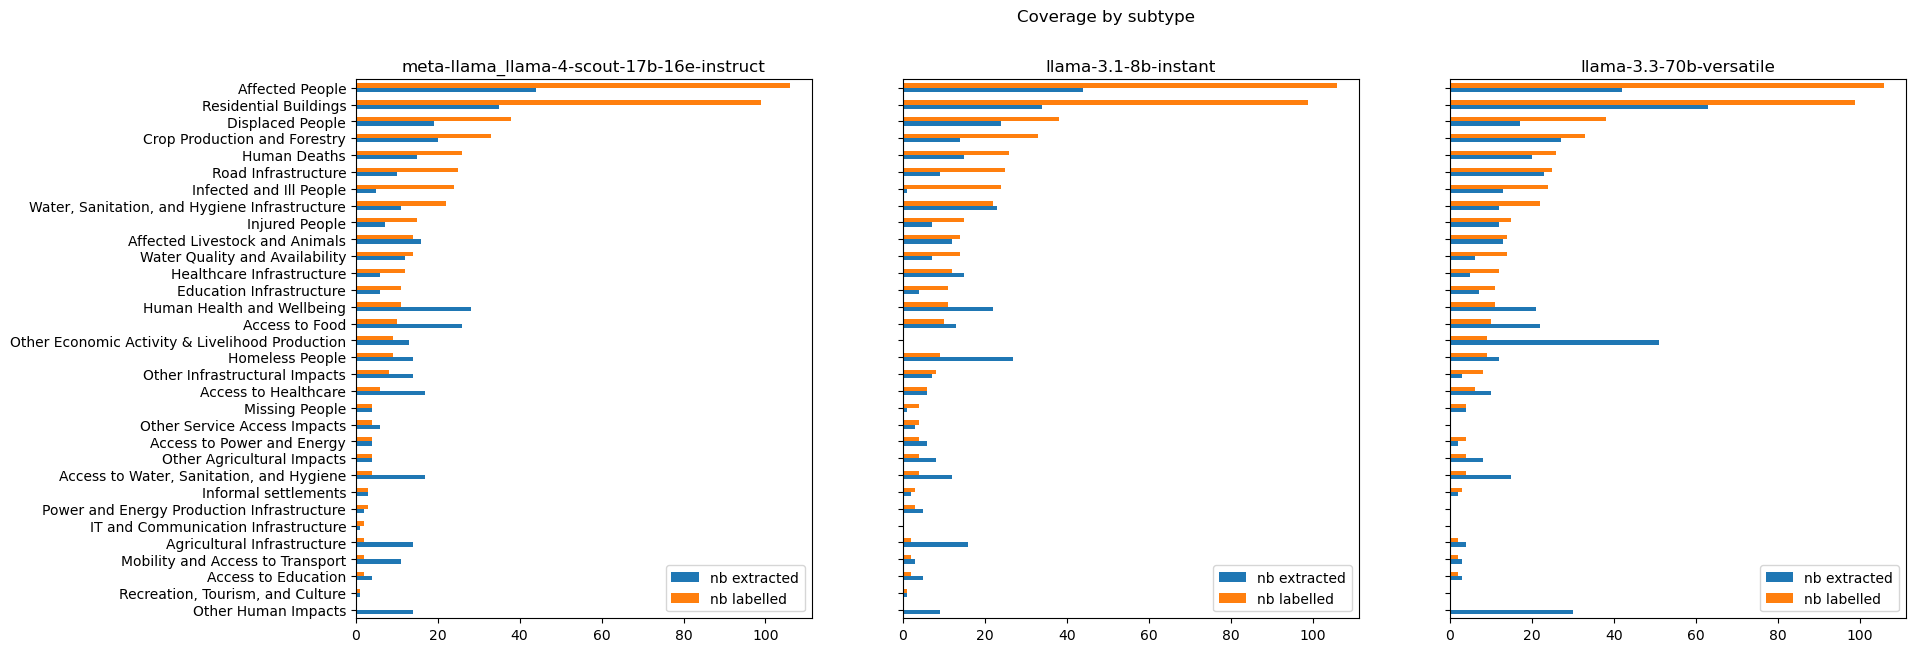

In [36]:
# compare different models
models = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
res_savename_ext1 = f"post_processed_labelled_reports_{models[0]}_v230925"
res_savename_ext2 = f"post_processed_labelled_reports_{models[1]}_v250925"
res_savename_ext3 = f"post_processed_labelled_reports_{models[2]}_v250925"

#load geocoded data
extracted_df1 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext1+".csv"))
extracted_df2 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext2+".csv"))
extracted_df3 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext3+".csv"))

coverage_subtype_df1 = make_coverage_subtype_df(extracted_df1, labelled_df)
coverage_subtype_df2 = make_coverage_subtype_df(extracted_df2, labelled_df)
coverage_subtype_df3 = make_coverage_subtype_df(extracted_df3, labelled_df)

fig, axes = plt.subplots(1, 3 ,figsize=(20,7), sharey=False, sharex=True)
label = coverage_subtype_df1[["nb extracted", "nb labelled"]].sort_values("nb labelled", ascending=True).index
coverage_subtype_df1[["nb extracted", "nb labelled"]].reindex(label).plot(kind="barh", ax=axes[0])
coverage_subtype_df2[["nb extracted", "nb labelled"]].reindex(label).plot(kind="barh", ax=axes[1])
coverage_subtype_df3[["nb extracted", "nb labelled"]].reindex(label).plot(kind="barh", ax=axes[2])

axes[0].set_title(models[0])
axes[1].set_title(models[1])
axes[2].set_title(models[2])

axes[1].set_yticklabels([])
axes[2].set_yticklabels([])

fig.suptitle("Coverage by subtype")

In [20]:
#spatial coverage by report
spatial_cov_appeal_lab = labelled_df.groupby("appealCode").locationLowestAdmin.value_counts().unstack()
spatial_cov_appeal_ext = extracted_df.groupby("appealCode").locationLowestAdmin.value_counts().unstack()
spatial_cov_appeal_df = pd.concat([spatial_cov_appeal_lab, spatial_cov_appeal_ext], keys=["labelled","extracted"],axis=1, join="inner")

<Axes: title={'center': 'Extracted'}, ylabel='appealCode'>

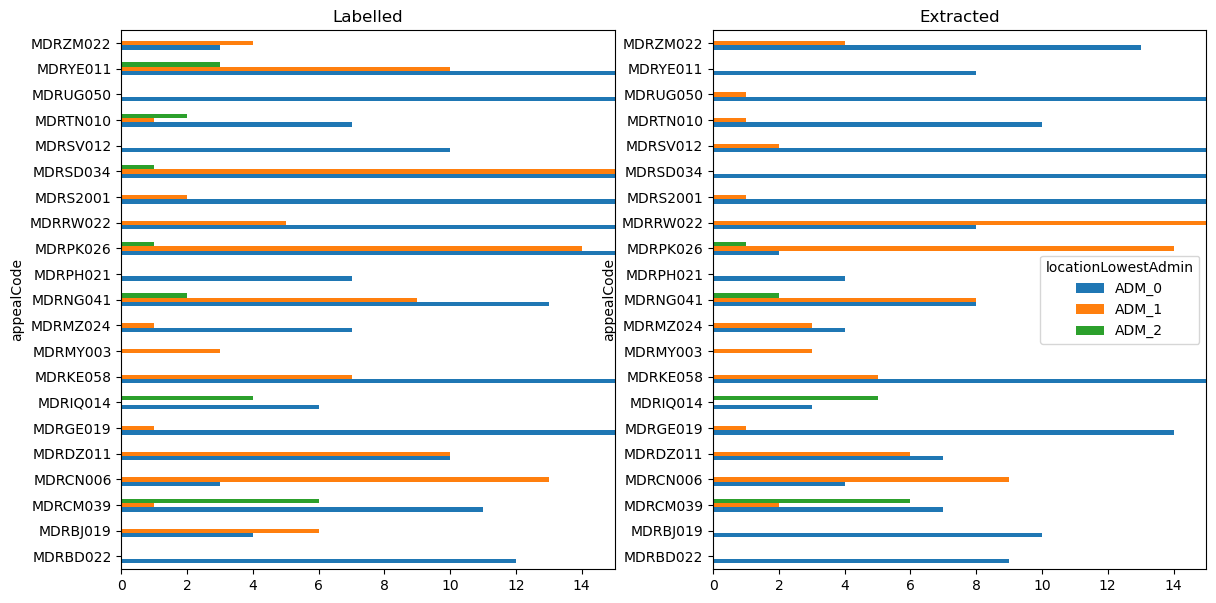

In [21]:
fix, axes = plt.subplots(1,2, figsize=(14, 7))
spatial_cov_appeal_df["labelled"].plot(kind="barh", ax=axes[0], legend=False,title="Labelled", xlim=[0,15])
spatial_cov_appeal_df["extracted"].plot(kind="barh", ax=axes[1], title="Extracted",xlim=[0,15])

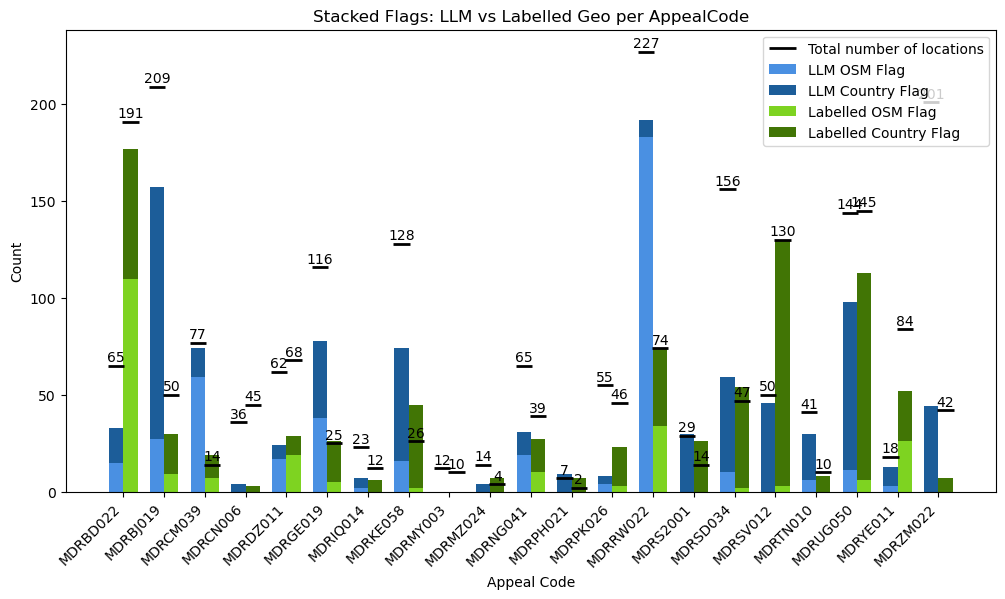

In [23]:
# Compute number of locations per row
for df in [extracted_df, labelled_df]:
    df['num_locations'] = df['location'].apply(
        lambda x: len(x) if isinstance(x, (list, tuple)) else (0 if pd.isna(x) else 1)
    )

# Group by appealCode
grouped_llm = extracted_df.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

grouped_labelled = labelled_df.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

# Set bar width and positions
bar_width = 0.35
x = np.arange(len(grouped_llm['appealCode']))

fig, ax = plt.subplots(figsize=(12,6))

# Colors
llm_colors = ['#4A90E2', '#1C5D99']       # Light blue, dark blue
labelled_colors = ['#7ED321', '#417505']  # Light green, dark green

# LLM bars
ax.bar(x - bar_width/2, grouped_llm['geocoding_osm_flag'], bar_width, color=llm_colors[0], label='LLM OSM Flag')
ax.bar(x - bar_width/2, grouped_llm['geocoding_country_flag'], bar_width,
       bottom=grouped_llm['geocoding_osm_flag'], color=llm_colors[1], label='LLM Country Flag')

# Labelled bars
ax.bar(x + bar_width/2, grouped_labelled['geocoding_osm_flag'], bar_width, color=labelled_colors[0], label='Labelled OSM Flag')
ax.bar(x + bar_width/2, grouped_labelled['geocoding_country_flag'], bar_width,
       bottom=grouped_labelled['geocoding_osm_flag'], color=labelled_colors[1], label='Labelled Country Flag')

# Plot total reports as lines
for i in range(len(x)):
    ax.hlines(y=grouped_llm['num_locations'][i], xmin=i - bar_width/2 - 0.2, xmax=i - bar_width/2 + 0.2,
              color='black', lw=2, label='Total number of locations' if i==0 else "")
    ax.text(i - bar_width/2, grouped_llm['num_locations'][i] + 0.5, str(grouped_llm['num_locations'][i]),
            ha='center', va='bottom', fontsize=10)

    ax.hlines(y=grouped_labelled['num_locations'][i], xmin=i + bar_width/2 - 0.2, xmax=i + bar_width/2 + 0.2,
              color='black', lw=2)
    ax.text(i + bar_width/2, grouped_labelled['num_locations'][i] + 0.5, str(grouped_labelled['num_locations'][i]),
            ha='center', va='bottom', fontsize=10)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(grouped_llm['appealCode'], rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_xlabel('Appeal Code')
ax.set_title('Stacked Flags: LLM vs Labelled Geo per AppealCode')
ax.legend()
fig.savefig(DATA_FIGURE /'counts_flags_appealCode_llm-labelled.png', dpi=300, bbox_inches='tight', transparent=True)